# Week 3 Day 4 Morning: Breadth First Search 

In [4]:
%run "boaz_utils.ipynb"

## Graph connectivity: functions from last time

In [5]:
def neighbors(G,u):
    return G[u]

def isedge(G,u,v):
    return v in neighbors(G,u)

def vertices(G):
    return list(range(len(G)))

def addedge(G,i,j): 
    if not j in G[i]:
        G[i].append(j)
        
def emptygraph(n):
    return [[] for i in range(n)]

In [6]:
def undirect(G):
    U = emptygraph(len(G))
    for u in vertices(G):
        for v in neighbors(G, u):
            addedge(U, u, v)
            addedge(U, v, u)
    return U

## What order does DFS visit vertices in this graph?

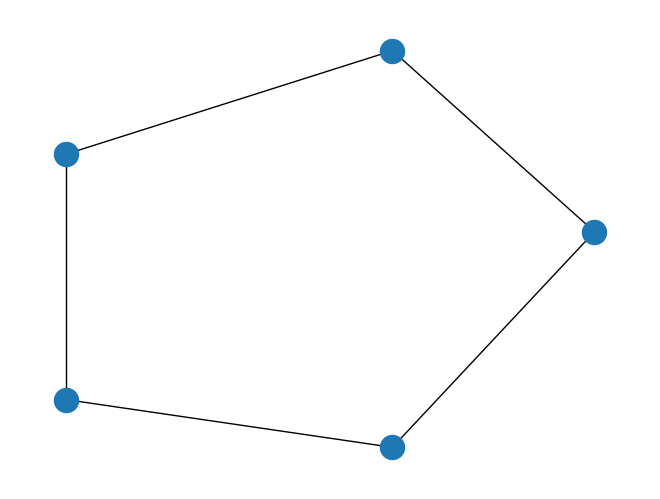

In [11]:
G = undirect([[1,4],[2],[3],[4],[0]])
draw_graph(G)

## Another algorithm for exploring graphs: Breadth First Search

In [7]:
# needs a queue
# we'll represent the queue as a pair (idx, L)
# where the active elements still in the queue are L[idx:]
def create_queue():
    return [0, []]

def enqueue(Q, x):
    Q[1].append(x)
    
def dequeue(Q):
    ans = Q[1][Q[0]]
    Q[0] += 1
    return ans

def queue_size(Q):
    return len(Q[1]) - Q[0]

In [8]:
# return list L indicating which vertices have and haven't been visited
# L[u] is True if and only if the source can reach u
def bfs(source, G):
    visited = [False]*len(G)
    Q = create_queue()
    
    enqueue(Q, source)
    visited[source] = True
    
    while queue_size(Q) > 0:
        u = dequeue(Q)
        for v in neighbors(G, u):
            if not visited[v]:
                enqueue(Q, v)
                visited[v] = True
    
    return visited

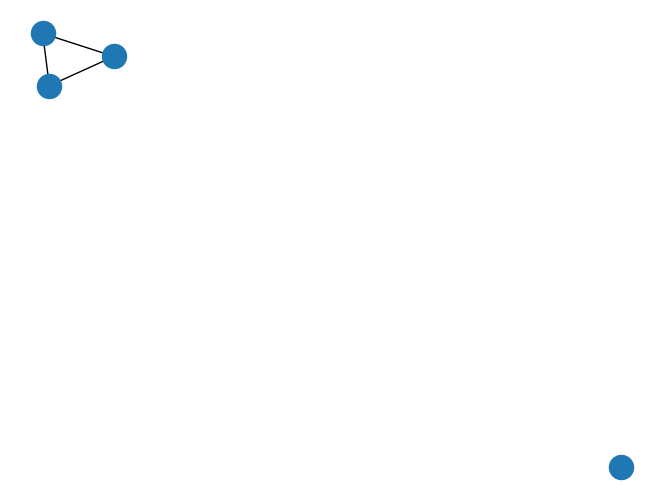

In [9]:
G = undirect([[1],[2],[0],[]])
draw_graph(G)

In [10]:
print(bfs(0, G))

[True, True, True, False]


## Can use Breadth First Search to find distances in graph

In [11]:
# breadth first search
def bfs(source, G):
    visited = [False]*len(G)
    dist = [float('infinity')]*len(G)
    Q = create_queue()
    
    enqueue(Q, source)
    visited[source] = True
    dist[source] = 0
    
    while queue_size(Q) > 0:
        u = dequeue(Q)
        for v in neighbors(G, u):
            if not visited[v]:
                dist[v] = dist[u] + 1
                visited[v] = True
                enqueue(Q, v)
    
    return dist

In [12]:
bfs(0, G)

[0, 1, 1, inf]

## How do we extract the actual path?

In [13]:
# return path in G from source to target
def bfs(source, target, G):
    visited = [False]*len(G)
    dist = [None]*len(G)
    backstep = [None]*len(G)
    
    Q = create_queue()
    enqueue(Q, source)
    visited[source] = True
    dist[source] = 0
    
    while queue_size(Q) > 0:
        u = dequeue(Q)
        for v in neighbors(G, u):
            if not visited[v]:
                enqueue(Q, v)
                visited[v] = True
                dist[v] = dist[u] + 1
                backstep[v] = u

    if visited[target] == False:
        return None

    path = [target]
    while backstep[path[-1]] != None:
        path.append(backstep[path[-1]])
                
    return path[::-1]

In [15]:
G = [
    [1,2],   # neighbors of 0
    [0,2,3], # neighbors of 1
    [0,1,4], # neighbors of 2
    [1,4],   # neighbors of 3
    [2,3]    # neighbors of 4
]

In [16]:
print(bfs(0, 4, G))

[0, 2, 4]
